<a href="https://colab.research.google.com/github/agatastachowiak/eeg-motor-imagery-bci/blob/main/notebooks/03_cnn_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mne

In [ ]:
import numpy as np
import mne
from mne.datasets import eegbci
import os
os.makedirs('/root/mne_data', exist_ok=True)

mne.set_log_level('WARNING')
mne.set_config('MNE_DATASETS_EEGBCI_PATH', '/root/mne_data')

subjects = list(range(1, 11))
runs = [4, 8, 12]

all_epochs_data = []
all_labels = []

for subj in subjects:
    raw_fnames = eegbci.load_data(subj, runs)
    raws = [mne.io.read_raw_edf(f, preload=True) for f in raw_fnames]
    raw = mne.concatenate_raws(raws)
    raw.filter(l_freq=8, h_freq=30)

    events, event_id = mne.events_from_annotations(raw)
    picks = {k: v for k, v in event_id.items() if k in ['T1', 'T2']}

    epochs = mne.Epochs(raw, events, event_id=picks, tmin=-0.5, tmax=2.0,
                         baseline=None, preload=True)

    epochs_data = epochs.get_data()
    labels = epochs.events[:, -1]

    all_epochs_data.append(epochs_data)
    all_labels.append(labels)
    print(f"Subject {subj}: {epochs_data.shape[0]} epochs")

X_all_epochs = np.concatenate(all_epochs_data, axis=0)
y_all = np.concatenate(all_labels, axis=0)

# CNN needs labels as 0/1, not 2/3 -- shift them down by 2
y_all = y_all - 2

print("Data shape:", X_all_epochs.shape)
print("Labels shape:", y_all.shape, "unique labels:", np.unique(y_all))

Subject 1: 45 epochs


Subject 2: 45 epochs


Subject 3: 45 epochs


Subject 4: 45 epochs


Subject 5: 45 epochs


Subject 6: 45 epochs


Subject 7: 45 epochs


Subject 8: 45 epochs


Subject 9: 45 epochs


Subject 10: 45 epochs
Data shape: (450, 64, 401)
Labels shape: (450,) unique labels: [0 1]


Goal: CNN that reads the raw EEG signal directly (64 channels × 401 timepoints per epoch) and learns to classify left vs. right fist imagery — no manual feature extraction like CSP did.

In [ ]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into train/validation sets, stratified so both sets keep the same
# proportion of each class (important to have fair comparison)
X_train, X_val, y_train, y_val = train_test_split(
    X_all_epochs, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Standardize each channel: subtract mean, divide by std -- computed on
# training data only, then applied to both sets (avoids leaking test info)
n_epochs_train, n_channels, n_times = X_train.shape
scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train.reshape(n_epochs_train, -1))
X_val_flat = scaler.transform(X_val.reshape(X_val.shape[0], -1))

X_train_scaled = X_train_flat.reshape(n_epochs_train, n_channels, n_times)
X_val_scaled = X_val_flat.reshape(X_val.shape[0], n_channels, n_times)

# Convert to PyTorch tensors, adding a "channel dimension" CNNs expect
# (shape becomes: batch, 1, channels, timepoints -- treating EEG like a 1-channel "image")
X_train_t = torch.FloatTensor(X_train_scaled).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val_scaled).unsqueeze(1)
y_train_t = torch.LongTensor(y_train)
y_val_t = torch.LongTensor(y_val)

print("Train shape:", X_train_t.shape)
print("Val shape:", X_val_t.shape)

Train shape: torch.Size([360, 1, 64, 401])
Val shape: torch.Size([90, 1, 64, 401])


**This CNN:** A compact EEGNet-style architecture. The key idea is that instead of us hand-picking features like CSP did, the network has layers that learn which spatial patterns across channels matter and which temporal patterns over time matter — stacked together, then a final classifier layer.

In [ ]:
class SimpleEEGNet(nn.Module):
    def __init__(self, n_channels=64, n_times=401, n_classes=2):
        super().__init__()

        # "forward": defines the actual path data takes through the network
        # temporal patterns → spatial patterns → combine → classify

        # Block 1: learn temporal patterns (filters slide across TIME, one channel at a time)
        self.temporal_conv = nn.Conv2d(1, 8, kernel_size=(1, 64), padding=(0, 32))
        self.bn1 = nn.BatchNorm2d(8)

        # Block 2: learn spatial patterns (filters slide across CHANNELS,
        # combining info across all 64 electrodes -- similar goal to CSP,
        # but learned by the network itself rather than hand-designed)
        self.spatial_conv = nn.Conv2d(8, 16, kernel_size=(n_channels, 1), groups=8)
        self.bn2 = nn.BatchNorm2d(16)
        self.elu = nn.ELU()
        self.pool1 = nn.AvgPool2d((1, 4))
        self.dropout1 = nn.Dropout(0.5)

        # Block 3: a second convolution to combine patterns further, then pool again
        self.separable_conv = nn.Conv2d(16, 16, kernel_size=(1, 16), padding=(0, 8))
        self.bn3 = nn.BatchNorm2d(16)
        self.pool2 = nn.AvgPool2d((1, 8))
        self.dropout2 = nn.Dropout(0.5)

        # Final classifier: flatten everything into one vector, then map to 2 class scores
        self.flatten = nn.Flatten()
        self.classifier = nn.LazyLinear(n_classes)  # LazyLinear figures out input size automatically

    def forward(self, x):
        x = self.temporal_conv(x)
        x = self.bn1(x)

        x = self.spatial_conv(x)
        x = self.bn2(x)
        x = self.elu(x)
        x = self.pool1(x)
        x = self.dropout1(x)

        x = self.separable_conv(x)
        x = self.bn3(x)
        x = self.elu(x)
        x = self.pool2(x)
        x = self.dropout2(x)

        x = self.flatten(x)
        x = self.classifier(x)
        return x

model = SimpleEEGNet()
print(model)

SimpleEEGNet(
  (temporal_conv): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (spatial_conv): Conv2d(8, 16, kernel_size=(64, 1), stride=(1, 1), groups=8)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (elu): ELU(alpha=1.0)
  (pool1): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
  (dropout1): Dropout(p=0.5, inplace=False)
  (separable_conv): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8))
  (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  (dropout2): Dropout(p=0.5, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): LazyLinear(in_features=0, out_features=2, bias=True)
)


**Next training loop:** repeatedly show the model batches of training data, measure how wrong its predictions are (loss), and nudge its internal weights to do better — for several passes through the full dataset.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Wrap our tensors into a Dataset, then a DataLoader that hands out batches automatically
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Loss function: standard choice for multi-class (here: 2-class) classification
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam is a reliable, commonly-used default that adapts the learning
# rate automatically as training progresses
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 30  # how many full passes through the training data

for epoch in range(n_epochs):
    model.train()  # tells the model it's in training mode (activates dropout, etc.)
    total_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()          # clear gradients from the previous step
        outputs = model(batch_X)       # forward pass: get predictions
        loss = criterion(outputs, batch_y)  # measure how wrong they are
        loss.backward()                # backpropagation: compute how to adjust weights
        optimizer.step()               # actually update the weights
        total_loss += loss.item()

    # Every 5 epochs, check performance on the validation set (data the model never trains on)
    if (epoch + 1) % 5 == 0:
        model.eval()  # switches off dropout etc. for a clean evaluation
        with torch.no_grad():  # we don't need gradients here, just predictions
            val_outputs = model(X_val_t)
            val_preds = val_outputs.argmax(dim=1)
            val_acc = (val_preds == y_val_t).float().mean().item()
        print(f"Epoch {epoch+1}/{n_epochs} - Train loss: {total_loss/len(train_loader):.4f} - Val accuracy: {val_acc:.4f}")

Epoch 5/30 - Train loss: 0.6834 - Val accuracy: 0.4000
Epoch 10/30 - Train loss: 0.6451 - Val accuracy: 0.4667
Epoch 15/30 - Train loss: 0.5965 - Val accuracy: 0.5111
Epoch 20/30 - Train loss: 0.5711 - Val accuracy: 0.4667
Epoch 25/30 - Train loss: 0.5228 - Val accuracy: 0.5000
Epoch 30/30 - Train loss: 0.5255 - Val accuracy: 0.5333


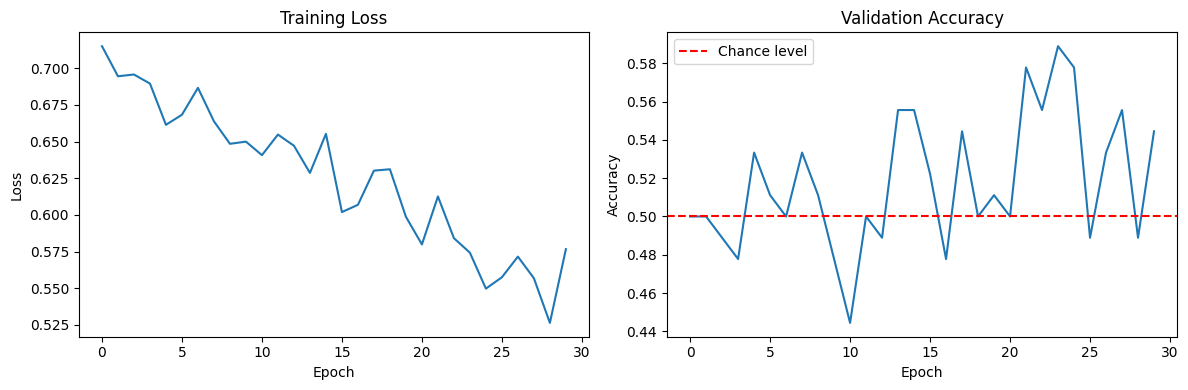

In [ ]:
import matplotlib.pyplot as plt

train_losses = []
val_accuracies = []

# Re-initialize the model so we start fresh with full history tracking
model = SimpleEEGNet()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_preds = val_outputs.argmax(dim=1)
        val_acc = (val_preds == y_val_t).float().mean().item()
    val_accuracies.append(val_acc)

# Plot both curves side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(val_accuracies)
axes[1].axhline(y=0.5, color='red', linestyle='--', label='Chance level')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

##**Overfitting**
Training loss is steadily decreasing (0.68 → 0.52) so the model is learning something about the training data and is consistently getting better at fitting the training data.
Validation accuracy stays flat around 45-53%, essentially chance level, with no clear upward trend. It dips as low as 44% and peaks as high as 59%, but centers right on chance.
**So the model is memorizing training examples, not learning generalizable signal.**

Most likely reason: 360 training examples is very small for a neural network. CNNs typically need thousands+ of examples to learn robust patterns

In [ ]:
# Scaling from 10 to 50 subjects
subjects = list(range(1, 51))   # scaled up from 10 to 50
runs = [4, 8, 12]

all_epochs_data = []
all_labels = []

for subj in subjects:
    raw_fnames = eegbci.load_data(subj, runs)
    raws = [mne.io.read_raw_edf(f, preload=True) for f in raw_fnames]
    raw = mne.concatenate_raws(raws)
    raw.filter(l_freq=8, h_freq=30)

    events, event_id = mne.events_from_annotations(raw)
    picks = {k: v for k, v in event_id.items() if k in ['T1', 'T2']}

    epochs = mne.Epochs(raw, events, event_id=picks, tmin=-0.5, tmax=2.0,
                         baseline=None, preload=True)

    epochs_data = epochs.get_data()
    labels = epochs.events[:, -1]

    all_epochs_data.append(epochs_data)
    all_labels.append(labels)
    print(f"Subject {subj}: {epochs_data.shape[0]} epochs")

X_all_epochs_50 = np.concatenate(all_epochs_data, axis=0)
y_all_50 = np.concatenate(all_labels, axis=0) - 2  # shift labels to 0/1

print("Data shape:", X_all_epochs_50.shape)
print("Labels shape:", y_all_50.shape)

Subject 1: 45 epochs
Subject 2: 45 epochs
Subject 3: 45 epochs
Subject 4: 45 epochs
Subject 5: 45 epochs
Subject 6: 45 epochs
Subject 7: 45 epochs
Subject 8: 45 epochs
Subject 9: 45 epochs


Subject 10: 45 epochs


Subject 11: 45 epochs


Subject 12: 45 epochs


Subject 13: 45 epochs


...

Subject 46: 45 epochs


Subject 47: 45 epochs


Subject 48: 45 epochs


Subject 49: 45 epochs


Subject 50: 45 epochs
Data shape: (2250, 64, 401)
Labels shape: (2250,)


In [ ]:
# rerun on 50-subject data
# CSP + SVM (quick, for comparison)

from mne.decoding import CSP
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
clf = make_pipeline(csp, SVC(kernel='linear'))

scores = cross_val_score(clf, X_all_epochs_50, y_all_50, cv=5)
print("CSP+SVM (50 subjects) - Cross-validation scores:", scores)
print("CSP+SVM (50 subjects) - Mean accuracy:", scores.mean())

CSP+SVM (50 subjects) - Cross-validation scores: [0.55111111 0.61777778 0.58666667 0.65111111 0.64888889]
CSP+SVM (50 subjects) - Mean accuracy: 0.611111111111111


### Interpretation: CSP+SVM, 50 subjects (pooled)

Mean accuracy: 61.1% (up from 53.3% with 10 subjects), with all 5 cross-validation
folds now consistently above the 50% chance level.

Scaling from 10 to 50 subjects meaningfully improved pooled classification
performance. This suggests that with more subjects, the model has enough diversity
to learn patterns that generalize across individuals, rather than being dominated
by any single person's idiosyncratic signal characteristics. This is consistent
with findings in the BCI literature that larger, more diverse training pools help
general (non-subject-specific) models perform better.

This result stands in contrast to the within-subject analysis from the 10-subject
experiment, where individual accuracy varied widely (44.7%–86.7%) — here, pooling
more subjects is starting to close that gap, though not fully: single-subject
decoding at its best (86.7%) still outperforms the best pooled result (61.1%),
showing subject-specific calibration remains advantageous when it's an option.

In [ ]:
# rerun on 50-subject data
# CNN — rebuild the train/val split and retrain

X_train, X_val, y_train, y_val = train_test_split(
    X_all_epochs_50, y_all_50, test_size=0.2, random_state=42, stratify=y_all_50
)

n_epochs_train, n_channels, n_times = X_train.shape
scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train.reshape(n_epochs_train, -1))
X_val_flat = scaler.transform(X_val.reshape(X_val.shape[0], -1))

X_train_scaled = X_train_flat.reshape(n_epochs_train, n_channels, n_times)
X_val_scaled = X_val_flat.reshape(X_val.shape[0], n_channels, n_times)

X_train_t = torch.FloatTensor(X_train_scaled).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val_scaled).unsqueeze(1)
y_train_t = torch.LongTensor(y_train)
y_val_t = torch.LongTensor(y_val)

print("Train shape:", X_train_t.shape)
print("Val shape:", X_val_t.shape)

# Rebuild everything fresh for this larger dataset
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # slightly bigger batch, because more data now

model = SimpleEEGNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_accuracies = []
n_epochs = 30

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_preds = val_outputs.argmax(dim=1)
        val_acc = (val_preds == y_val_t).float().mean().item()
    val_accuracies.append(val_acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Train loss: {avg_loss:.4f} - Val accuracy: {val_acc:.4f}")

Train shape: torch.Size([1800, 1, 64, 401])
Val shape: torch.Size([450, 1, 64, 401])
Epoch 5/30 - Train loss: 0.6807 - Val accuracy: 0.5556
Epoch 10/30 - Train loss: 0.6409 - Val accuracy: 0.6311
Epoch 15/30 - Train loss: 0.6104 - Val accuracy: 0.6556
Epoch 20/30 - Train loss: 0.5849 - Val accuracy: 0.6711
Epoch 25/30 - Train loss: 0.5695 - Val accuracy: 0.6667
Epoch 30/30 - Train loss: 0.5572 - Val accuracy: 0.6444


### Interpretation: CNN, 50 subjects (pooled)

Validation accuracy climbed from ~50% (chance, with 10 subjects — see overfitting
plot above) to 64–67% with 50 subjects, while training loss continued its smooth
downward trend in both cases.

This demonstrates that CNNs
require substantially more data than classical methods to learn generalizable
patterns. With only 360 training examples (10 subjects), the network had enough
capacity to memorize the training set without learning transferable features
(training loss dropped, validation accuracy did not). With 1,800 training examples
(50 subjects), the same architecture successfully learned generalizable patterns
— and modestly outperformed CSP+SVM at the same scale (~66% vs. 61.1%).

This suggests that once sufficient data is available, the CNN can extract
information from the raw signal beyond what hand-engineered CSP spatial filters
capture. Practically, this reflects a common real-world tradeoff: classical
methods like CSP+SVM are more data-efficient and reliable in small-data regimes,
while deep learning becomes competitive — and eventually superior — only once
enough training data is available.

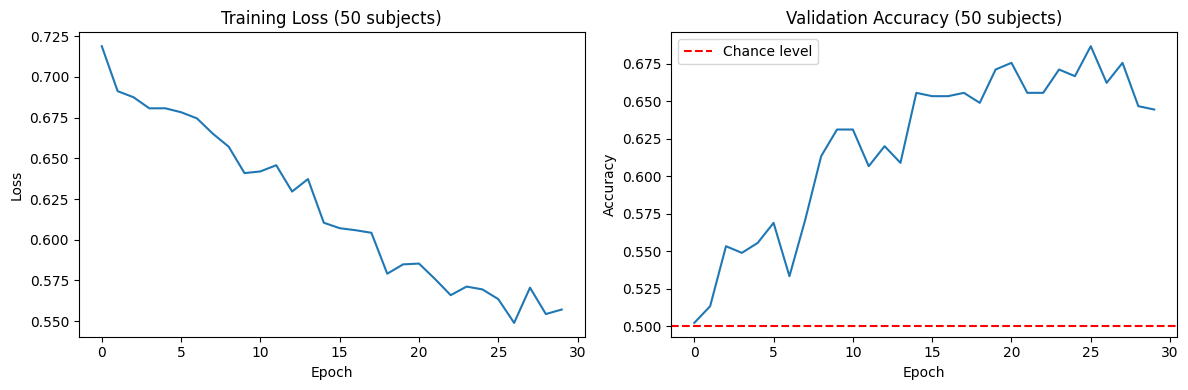

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses)
axes[0].set_title('Training Loss (50 subjects)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(val_accuracies)
axes[1].axhline(y=0.5, color='red', linestyle='--', label='Chance level')
axes[1].set_title('Validation Accuracy (50 subjects)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_training_curves_50subj.png', dpi=150, bbox_inches='tight')
plt.show()